# Projet: Introduction au machine learning, partie I

Le projet est à rendre sur Moodle, avant le 13 février, 8h du matin. La séance du 13 février sera consacrée à une mini-soutenance lors de laquelle vous présenterez ce notebook, votre code et vos résultats numériques. Vous pouvez faire le projet par groupe de 2. 

Noms des étudiants:  Nader et Perret.



**But du projet**

Le but de ce projet est d'implémenter un classificateur de spam. Pour cela, on utilisera un jeu de donnée public disponible sur
https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset?resource=download

## Question 1: préparation des données: importation, nétoyage et formatage

Télécharger les données et écrire une fonction qui:
- importer les données en python (attention, il peut y avoir un soucis d'encodage. Vous pouvez utiliser `pd.read_csv('spam.csv', encoding="latin1")`)
- remplace les majuscules par des minuscules.

Indication: On pourra utiliser la bibliothèque python `re`: https://docs.python.org/3/library/re.html

Ensuite:
- Importer les données et ensuite créez deux listes: `texts`, `labels`.
- Regarder la documentation de `CountVectorizer` et:
    - expliquer ce que fait cette fonction et notamment le paramètre `max_features`
    - appliquer la à vos textes pour écrire une fonction qui rend un vecteurs `features` où chaque texte est remplacé par un vecteur qui compte les occurences des différents mots.

La fonction transorme une liste de texte en une matrice de tokens donc de valeurs
pour chaque mots presents dans la liste ils creer un dictionnaire avec tous les mots et leurs fréquences.

max_features permet de garder seulement les mots avec la plus grosse frequences par exemple les 1000 plus gros etc 

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

data=pd.read_csv('spam.csv', encoding="latin1")
data=data[['v1','v2']]
def nettoyer_texte(texte):
    return texte.lower()
data['v2'] = data ['v2'].apply(nettoyer_texte)
texts = data ['v2']
labels = data ['v1']
max=5000
vectorizer = CountVectorizer(max_features=max)
features=vectorizer.fit_transform(texts)
features=features.toarray()

## Question 2: Modèle logistique 

Implémenter une classe python qui implémente un modèle logistique et fait des mises à jour de gradient.  On rappelle que la prédiction d'un tel modèle est $f(x; w)= \sigma(x^Tw)$ et que la loss est $l(\hat{y}, y) = -y\log(\hat{y}) - (1-y)\log(1-\hat{y})$


In [11]:
import numpy as np

class LogisticRegressionSGD:
    def __init__(self, input_dim, alpha):
        self.w = np.zeros(input_dim)
        self.temp=0
        self.alpha = alpha 

    def sigmoid(self, z):
        return 1/(1+np.exp(-z))

    def predict_proba(self, x):
        poids= np.dot(self.w,x)
        return self.sigmoid(poids)

    def predict_zero_un(self, x):
        if self.predict_proba(x) >= 0.5 :
            return 1
        else :
            return 0

    def loss(self, x, y):
            p=self.predict_proba(x)
            epsilon = 1e-15
            p = np.clip(p, epsilon, 1 - epsilon)
            return -y*np.log(p)-(1-y)*np.log(1-p)

    def update(self, x, y):
        gradient=(self.predict_proba(x)-y)*x
        self.w=self.w-self.alpha(self.temp)*gradient
        self.temp+=1

## Classe pour Adaline

In [12]:
# Classe pour le modèle Adaline

class AdalineRegressionSGD:
    def __init__(self, input_dim, alpha):
        self.w = np.zeros(input_dim)
        self.temp=0
         # pas
        self.alpha = alpha 

    def predict_proba(self,x):
        return np.dot(self.w, x)
    
    def predict_zero_un(self, x):
        if self.predict_proba(x)>=0 :
            return 1
        else :
            return -1
        
    def loss(self, x, y):
        return 1/2 * (y - self.predict_proba(x))**2
    
    def update(self, x, y):
        gradient=(self.predict_proba(x)-y)*x
        self.w=self.w-self.alpha(self.temp)*gradient
        self.temp+=1

## Question 3: Modèle Adaline 

En s'inspirant de la classe ci dessus, créer une classe qui implémente un modèle Adaline. Pour ce modèle, la prédiction est $f(x; w)=x^Tw$ et la fonction de perte est $l(\hat{y}, y) = \frac12(y - \hat{y})^2$.

## Quesiton 4: SGD

Écrire une fonction `sgd` qui prend en entrée un jeu d'entrainement, un jeu de teste et implémente l'algorithme de descente de gradient stochastique pour un des deux modèles.


In [13]:
def sgd(model, X_train, y_train, X_val, y_val, epochs=10):
    """
    Cette fonction fait "epochs" époques de 1000
    """
    train_losses = []   # Pour imprimer l'erreur d'apprentissage
    val_losses = []     # Pour imprimer l'erreur de validation

    for epoch in range(epochs):
        for i in range(1000):
            n = np.random.randint(len(X_train))
            x=X_train[n]
            y=y_train[n]
            model.update(x,y)
        calcul_perte_train=sum(model.loss(X_train[k],y_train[k])for k in range (len(X_train)))/len(X_train)
        calcul_perte_val=sum(model.loss((X_val[k]),y_val[k])for k in range (len(X_val)))/len(X_val)
        train_losses.append(calcul_perte_train)
        val_losses.append(calcul_perte_val)
    return train_losses, val_losses


## Question 5: préparation des résultats

Écrire une fonction qui permet de calculer la précision et l'a matrice de confusion:

In [14]:
def accuracy_brut(y_true, y_pred):
    correct=0
    for i in range(len(y_true)):
        if(y_true[i]==y_pred[i]):
            correct+=1
    return correct/len(y_true)


def confusion_matrix(y_true, y_pred):
    #Matrice [VP FP
    #         FN VN ]
    matrice= [[0,0], [0,0]]
    for  i in range (len(y_true)):
        if(y_true[i]==1 and y_pred[i]==1):
            matrice[0][0]+=1
        if(y_true[i]==0 and y_pred[i]==1):
            matrice[0][1]+=1
        if(y_true[i]==1 and y_pred[i]==0):
            matrice[1][0]+=1
        if(y_true[i]==0 and y_pred[i]==0):
            matrice[1][1]+=1
    return matrice

In [15]:
def confusion_matrix_ada(y_true, y_pred):
    #Matrice [VP FP
    #         FN VN ]
    matrice= [[0,0], [0,0]]
    for  i in range (len(y_true)):
        if(y_true[i]==1 and y_pred[i]==1):
            matrice[0][0]+=1
        if(y_true[i]==-1 and y_pred[i]==1):
            matrice[0][1]+=1
        if(y_true[i]==1 and y_pred[i]==-1):
            matrice[1][0]+=1
        if(y_true[i]==-1 and y_pred[i]==-1):
            matrice[1][1]+=1
    return matrice

## Question 6 : Étude numérique 

Appliquer l'algorithme de SGD à vos données et comparer les deux modèles. A chaque fois, trouver un pas d'apprentissage qui convient. 

Tester avec plusieurs paramètre de `max_features` et commentez les résultats.

Présentez la matrice de confusion et commentez. 

Nombre de mots utilisé: 5000, Nombre d'époque :50
Précision (Accuracy) : 96.41 %, valeur de perte empirique minimum 0.141 atteinte a l'époque 49 
------------------------------
Matrice de Confusion :
      [ VP=201   FP=33   ]
      [ FN=27    VN=1411 ]


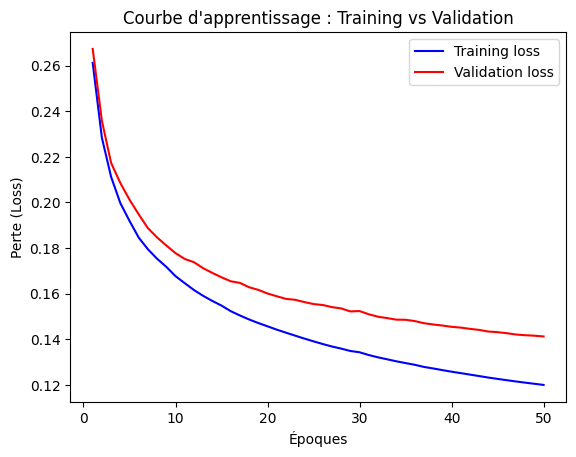

In [16]:
import matplotlib.pyplot as plt
def pas_inverse_racine(t):
    return 1/np.sqrt((1+t))
def pas_inverse(t):
    return 1/(1+t)
def pas_constant_01(t):
    return 0.1
def pas_constant_001(t):
    return 0.01
y_true = []
epoch=50
for i in range (len(labels)):
    if(labels[i]=="ham"):
        y_true.append(0)
    else:
        y_true.append(1)
separation = int(len(labels)*0.7)
X_train=features[:separation]
X_val=features[separation:]
Y_train=y_true[:separation]
Y_val=y_true[separation:]
machine=LogisticRegressionSGD(max,pas_inverse_racine)
train_losses,val_losses=sgd(machine,X_train,Y_train,X_val,Y_val,epoch)
perte_min=val_losses[0]
epoque_min=0
for i in range(len(val_losses)):
    if val_losses[i]<perte_min:
        perte_min=val_losses[i]
        epoque_min=i
y_pred= []
for i in range(len(Y_val)):
    y_pred.append(machine.predict_zero_un(X_val[i]))
matrice=confusion_matrix(Y_val,y_pred)
VP = matrice[0][0]
FP = matrice[0][1]
FN = matrice[1][0]
VN = matrice[1][1]
print(f"Nombre de mots utilisé: {max}, Nombre d'époque :{epoch}")
print(f"Précision (Accuracy) : {accuracy_brut(Y_val,y_pred) * 100:.2f} %, valeur de perte empirique minimum {perte_min:.3f} atteinte a l'époque {epoque_min} ")
print("-" * 30) # Une ligne de séparation
print("Matrice de Confusion :")
print(f"      [ VP={VP:<4}  FP={FP:<4} ]")  # <4 assure un espace de 4 caractères pour aligner
print(f"      [ FN={FN:<4}  VN={VN:<4} ]")
epoques = range(1,epoch+1)
plt.plot(epoques, train_losses, 'b', label='Training loss')
plt.plot(epoques, val_losses, 'r', label='Validation loss')

plt.title('Courbe d\'apprentissage : Training vs Validation')
plt.xlabel('Époques')
plt.ylabel('Perte (Loss)')
plt.legend()
plt.show()


In [20]:
# adaline

def pas(t):
    return 0.000001

y_true = []
epoch=50
for i in range (len(labels)):
    if(labels[i]=="ham"):
        y_true.append(-1)
    else:
        y_true.append(1)


separation = int(len(labels)*0.7)
X_train=features[:separation]
X_val=features[separation:]
Y_train=y_true[:separation]
Y_val=y_true[separation:]

mean_train = np.mean(X_train, axis=0)
std_train = np.std(X_train, axis=0)
std_train[std_train == 0] = 1 

X_std = (X_train - mean_train) / std_train
X_val_std = (X_val - mean_train) / std_train

machine=AdalineRegressionSGD(max,pas)
sgd(machine,X_std,Y_train,X_val_std,Y_val,epoch)

y_pred= []
for i in range(len(Y_val)):
    y_pred.append(machine.predict_zero_un(X_val_std[i]))
matrice=confusion_matrix_ada(Y_val,y_pred)
VP = matrice[0][0]
FP = matrice[0][1]
FN = matrice[1][0]
VN = matrice[1][1]
print(f"Nombre de mots utilisé: {max}, Nombre d'époque :{epoch}")
print(f"Précision (Accuracy) : {accuracy_brut(Y_val,y_pred) * 100:.2f} %")
print("-" * 30) # Une ligne de séparation
print("Matrice de Confusion :")
print(f"      [ VP={VP:<4}  FP={FP:<4} ]")  # <4 assure un espace de 4 caractères pour aligner
print(f"      [ FN={FN:<4}  VN={VN:<4} ]")


Nombre de mots utilisé: 5000, Nombre d'époque :50
Précision (Accuracy) : 97.55 %
------------------------------
Matrice de Confusion :
      [ VP=226   FP=39   ]
      [ FN=2     VN=1405 ]


# Question 7: pour aller plus loin

Trouver une autre jeu donnée de spam (par exemple sur kagle). Testet les modèles que vous avez appris sur votre jeu à ce nouveau jeu.